# Implementação da Arquitetura LeNet-5 em PyTorch

In [1]:
import torch
import torch.nn as nn

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        
        # ---  1. EXTRAÇÃO DE CARACTERÍSTICAS (FEATURES) ---
        # Esta parte da rede usa Convoluções para "enxergar" a imagem, procurando por 
        # padrões como bordas, cantos e texturas.
        # A rede original esperava imagens em escala de cinza e com tamanho 32x32 pixels.
        self.features = nn.Sequential(
            
            # 1ª CAMADA CONVOLUCIONAL:
            # in_channels=1: a imagem de entrada tem apenas 1 canal de cor (escala de cinza).
            # out_channels=6: estamos criando 6 "filtros" que vão produzir 6 representações (ou mapas) diferentes da imagem.
            # kernel_size=5: cada filtro olha para a imagem em pedaços (janelas) de 5x5 pixels.
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            
            # FUNÇÃO DE ATIVAÇÃO (ReLU):
            # Redes neurais precisam de matemática não-linear para aprender padrões abstratos e complexos.
            # Sem funções de ativação, o modelo seria apenas uma sequência de contas lineares simples.
            # ReLU resolve o problema do gradiente de desvanecimento e é mais rápida de calcular.
            nn.ReLU(),
            
            # 1º POOLING (Subamostragem via Max Pooling):
            # Ela diminui o tamanho espacial (largura e altura) da imagem pela metade. Isso torna a rede mais rápida 
            # computacionalmente e também ajuda a IA a reconhecer o padrão mesmo que ele mude um pouquinho de lugar.
            # Antes usávamos AvgPool (média). O MaxPool escolhe sempre o pixel mais 'forte' (valor mais alto) da janela.
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 2ª CAMADA CONVOLUCIONAL:
            # Agora recebemos os 6 "mapas" da camada anterior (in_channels=6) 
            # e aplicamos 16 filtros ainda mais complexos (out_channels=16).
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.ReLU(),
            
            # 2º POOLING:
            # Reduz as dimensões mais uma vez para condensar a essência da imagem pegando seus pontos principais.
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # --- 2. CLASSIFICAÇÃO (CLASSIFIER) ---
        # Aqui recebemos as características concentradas e purificadas pelas convoluções do passo 1
        # e usamos camadas densas (Lineares) para decidir qual classe (por ex, que dígito) está na imagem.
        self.classifier = nn.Sequential(
            
            # 1ª CAMADA LINEAR (Densa):
            # As convoluções e o pooling do passo anterior retornam pequenas "imagens" 2D (16 mapas de 5x5 pixels). 
            # Mas camadas Lineares precisam de um vetor plano e contínuo (em linha / modelo 1D). 
            # Então nós multiplicamos o tamanho total num achatamento: 16 * 5 * 5 = 400 valores numéricos.
            # A partir de 400 pontuações numéricas, a lógica matemática foca em apenas 120 na saída da camada.
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            
            # 2ª CAMADA LINEAR:
            # Peneira e condensa as informações ainda mais, transformando 120 conceitos base em 84.
            nn.Linear(120, 84),
            nn.ReLU(),
            
            # 3ª CAMADA LINEAR (Saída Final):
            # Transforma os últimos 84 valores no número final que designamos para turmas diferentes (saídas).
            # Como a LeNet-5 foi criada para prever os dígitos (0 a 9) manuscritos, ela usa "num_classes=10".
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        """
        A função `forward` dita exatamente como a matriz de dados flui através da rede na hora de treinar e prever.
        Para toda imagem `x` que alimentamos o PyTorch, ele executa os passos matemáticos abaixo na ordem declarada:
        """
        
        # PASSO 1: Passa a imagem bruta pela estrutura de extração visual das Convoluções / Pooling
        x = self.features(x)
        
        # PASSO 2: Achatamento da Matriz 2D/3D (Flatten)
        # Transforma o formato 4D [Lote, 16, 5, 5] resultante da Etapa 1 num plano 2D continuo [Lote, 400]
        # O termo "1" diz ao PyTorch: "Mantenha o tamanho do Lote (Batch) como a dimensão principal para o agrupamento, e achate o resto".
        x = torch.flatten(x, 1)
        
        # PASSO 3: Passa a linha sequencialmente achatada pelo cérebro classificador (Camadas Lineares) e gera o resultado.
        logits = self.classifier(x)
        
        # Os "logits" são os números brutos originais previstos pelo nosso modelo.
        # Usualmente transformamos isso em probabilidades (de 0 a 1 em uma curva) depois usando matemática de Softmax ou Log-Loss.
        return logits


---
### 🖼️ Visualizando o Estado Inicial dos Filtros

Antes do treinamento ser executado, os pesos (filtros convolucionais) de uma rede em PyTorch recebem valores aleatórios de inicialização.

Abaixo nós instanciamos o modelo e usamos a biblioteca `matplotlib` para ver as matrizes dos 6 filtros presentes na nossa 1ª camada de convolução.

Formato do tensor dos filtros obtido: (6, 1, 5, 5)
Existem 6 filtros diferentes, cada um com tamanho 5x5 aplicados no canal de entrada.



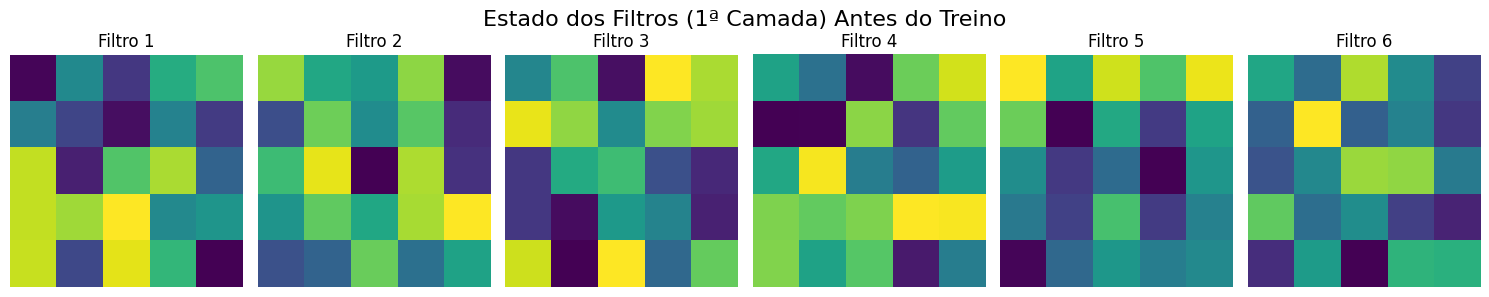

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Instanciar nossa rede (antes de ser treinada)
model = LeNet5()

# 2. Acessar os pesos correspondentes à primeira convolução (camada features[0])
# O bloco model.features[0] resgata o que definimos como nn.Conv2d(1, 6, kernel_size=5)
# Usamos .detach() porque não precisamos rastrear gradientes para visualização.
filters = model.features[0].weight.detach().cpu().numpy()

# As dimensões de um peso de Conv2d são: [out_channels, in_channels, altura, largura]
# Sendo assim, nosso shape será: (6, 1, 5, 5)
print(f"Formato do tensor dos filtros obtido: {filters.shape}")
print("Existem 6 filtros diferentes, cada um com tamanho 5x5 aplicados no canal de entrada.\n")

# 3. Criar uma renderização visual de cada filtro contido na camada
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for idx, ax in enumerate(axes):
    # Escolhemos o filtro de índice 'idx', vindo do primeiro canal de cor (0)
    f = filters[idx, 0, :, :]
    
    # Exibe matematicamente a intensidade dos pesos como uma imagem visual
    im = ax.imshow(f, cmap='viridis')
    ax.set_title(f'Filtro {idx+1}')
    ax.axis('off')

plt.suptitle('Estado dos Filtros (1ª Camada) Antes do Treino', fontsize=16)
plt.tight_layout()
plt.show()


---
### 🔢 Importando o Dataset MNIST

A **LeNet-5** foi concebida na década de 90 primariamente para reconhecer dígitos manuscritos e caracteres de leitura bancária. Hoje, utilizamos o clássico dataset **MNIST** que contém 60.000 imagens de dígitos (0 a 9) para treinamento e 10.000 para validação.

Vale ressaltar que a LeNet-5 espera uma imagem `32x32`, mas os dígitos do MNIST geralmente têm tamanho `28x28`. Vamos pedir ao pacote `torchvision` para realizar no momento de carregar as fotos uma técnica chamada de _Resize_ preenchendo as bordas, a fim de termos o tamanho exigido pela primeira Camada de Convolução.

O Dataset MNIST inteiro possui 60000 imagens de treinamento configuradas.
Formato de cada Lote retornado pelo DataLoader: torch.Size([64, 1, 32, 32]) => [Batch, Canal, Altura, Largura]


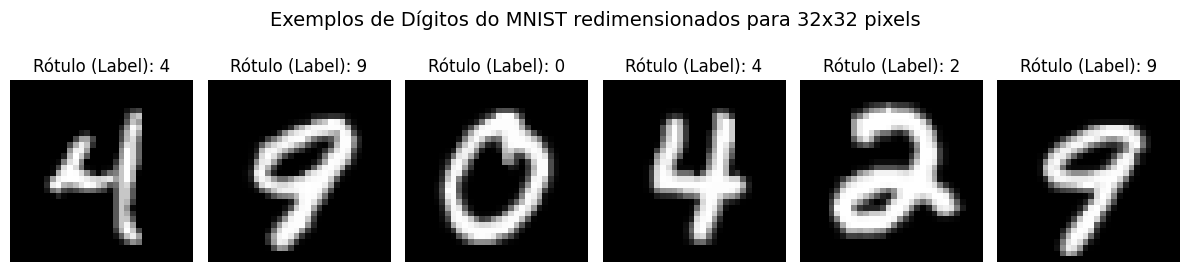

In [3]:
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
import torch

# 1. Definimos o fluxo de Transformação da Imagem (Data Augmentation / Pre-processing).
# - Resize(32, 32): Ajusta a imagem do MNIST de 28x28 para os 32x32 pixels exigidos pela LeNet
# - ToTensor(): Pega a imagem que varia de cor entre 0 ~ 255 e converte num formato Tensor do PyTorch entre 0.0 ~ 1.0
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

# 2. Fazemos o Download automático do Dataset a partir dos servidores públicos
# A flag train=True baixa os agrupamentos de aprendizagem principal (as 60.000 amostras)
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 3. Empacotamos com o DataLoader.
# Este componente vai organizar os Lotes de Treino (Batch). Como temos 60.000 fotos, treinar uma por uma é muito devagar. 
# Entregar 64 imagens por rodada pra GPU será ideal. 'shuffle=True' embaralha as imagens para dificultar o vício da rede.
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

print(f"O Dataset MNIST inteiro possui {len(train_dataset)} imagens de treinamento configuradas.")

# 4. Extraímos apenas uma batelada (1 lote) para visualizar.
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"Formato de cada Lote retornado pelo DataLoader: {images.shape} => [Batch, Canal, Altura, Largura]")

# 5. Desenhamos 6 exemplos pra gente analisar se o redimensionamento deu certo:
fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i in range(6):
    # Extrair a matrix de imagem do Batch
    image = images[i].squeeze()  # Remove a dimensão vazia '1' de Canal do Tensor, ou o matplotlib reclama
    
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Rótulo (Label): {labels[i].item()}')
    axes[i].axis('off')

plt.suptitle('Exemplos de Dígitos do MNIST redimensionados para 32x32 pixels', fontsize=14)
plt.tight_layout()
plt.show()


---
### 🏋️‍♂️ Iniciando o Treinamento da LeNet-5

Agora temos nossa IA estruturada em um bloco, bem como todos os nossos dados preparados em Lotes. Vamos prosseguir com a declaração dos últimos três componentes principais do motor de Treinamento:

1. **Dispositivo (GPU vs CPU):** A aceleração computacional por placas de vídeo.
2. **Loss Function (Função de Perda):** O método pela qual a máquina vai comparar sua previsão com o Gabarito (label real) da imagem e saber o quanto ela errou.
3. **Otimizador:** O motor matemático responsável por ir ajustando os pesos da rede em relação a "Perda" encontrada anteriormente.

In [5]:
import torch.optim as optim

# Verifica se existe uma Placa de Vídeo (GPU) disponível (NVIDIA CUDA ou Mac Metal/MPS)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Treinamento rodando na unidade: {device}")

# Movemos nosso modelo para a placa de vídeo (se ela existir)
model = LeNet5().to(device)

# --- FUNÇÃO DE PERDA (LOSS) ---
# CrossEntropy é a perda padrão para modelos clássicos de prever entre centenas/dezenas de classes isoladas.
criterion = nn.CrossEntropyLoss()

# --- OTIMIZADOR ---
# O Adam é uma versão aprimorada e rápida do famoro Gradient Descent (SGD).
# O 'lr' (Learning Rate ou Taxa de Apreziado) dita o tamanho da força aplicada a cada ajustada nos filtros matemáticos.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- LAÇO DE TREINAMENTO (Treino em si) ---
# 1 Época (Epoch) significa que a rede enxergou o seu dataset de 60.000 imagens pelo menos 1 única vez integral.
epochs = 5

print("\nIniciando o Treino...\n")
for epoch in range(epochs):
    running_loss = 0.0
    
    # Enumeramos cada lote (de 64 imagens cada) para progredir dentro do Dataset gigantesco
    for batch_idx, (images, labels) in enumerate(train_loader):
        # 1. Enviar lote de imagens e as repostas (gabaritos certinhos) pra Placa de Vídeo
        images, labels = images.to(device), labels.to(device)
        
        # 2. Zera os gradientes matemáticos do loop passado, pois o PyTorch naturalmente acumula as variaveis.
        optimizer.zero_grad()
        
        # 3. Faz a previsão bruta passando as imagens dentro de nosso Modelo LeNet-5 (o Forward Pass)
        outputs = model(images)
        
        # 4. Compara as previsões puras com os Rótulos verdadeiros usando a Cross Entropy para gerar uma pontuação do "Erro".
        loss = criterion(outputs, labels)
        
        # 5. Calcula o quanto cada neurônio dentro da rede precisa mudar e ser alterado para corrigir a pontuação do erro gerado 
        # (Propagação Reversa ou Backward Pass)
        loss.backward()
        
        # 6. Aplica a ação corretiva de fato nas variáveis da estrutura
        optimizer.step()
        
        # Armazeno a soma da perda nesse ciclo para gerar medições medias no nosso print log
        running_loss += loss.item()
        
        # Ao final de 200 lotes, imprimimos no Console a situação:
        if batch_idx % 200 == 199:
            print(f"[Época: {epoch + 1}, Progresso de Lotes: {batch_idx + 1}/{len(train_loader)}] -> Perda (Loss) calculada: {running_loss / 200:.4f}")
            running_loss = 0.0
            
print("\n✅ Treinamento da LeNet-5 Concluído com Sucesso!")


Treinamento rodando na unidade: cpu

Iniciando o Treino...

[Época: 1, Progresso de Lotes: 200/938] -> Perda (Loss) calculada: 0.7454
[Época: 1, Progresso de Lotes: 400/938] -> Perda (Loss) calculada: 0.2105
[Época: 1, Progresso de Lotes: 600/938] -> Perda (Loss) calculada: 0.1424
[Época: 1, Progresso de Lotes: 800/938] -> Perda (Loss) calculada: 0.1167
[Época: 2, Progresso de Lotes: 200/938] -> Perda (Loss) calculada: 0.0844
[Época: 2, Progresso de Lotes: 400/938] -> Perda (Loss) calculada: 0.0690
[Época: 2, Progresso de Lotes: 600/938] -> Perda (Loss) calculada: 0.0769
[Época: 2, Progresso de Lotes: 800/938] -> Perda (Loss) calculada: 0.0677
[Época: 3, Progresso de Lotes: 200/938] -> Perda (Loss) calculada: 0.0611
[Época: 3, Progresso de Lotes: 400/938] -> Perda (Loss) calculada: 0.0502
[Época: 3, Progresso de Lotes: 600/938] -> Perda (Loss) calculada: 0.0513
[Época: 3, Progresso de Lotes: 800/938] -> Perda (Loss) calculada: 0.0470
[Época: 4, Progresso de Lotes: 200/938] -> Perda (Lo

---
### 🧪 Avaliando o Modelo no Conjunto de Teste

Após o modelo treinar, precisamos garantir que ele realmente aprendeu a reconhecer padrões e não apenas decorou as 60.000 imagens.

Para isso, o dataset MNIST reserva 10.000 fotos de "teste" - imagens que a LeNet-5 nunca viu durante as Épocas passadas. Vamos passar essas imagens pela rede, desabilitar a atualização de gradientes (pois já terminamos o treino) e medir a porcentagem exata de Acertos (Acurácia).

In [6]:
# 1. Preparamos o DataLoader, só que desta vez baixamos e usamos a aba 'train=False' (as 10 mil de teste).
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)

# Contadores para medir o nosso sucesso e precisão:
correct = 0
total = 0

# 2. Colocar o modelo em modo de "Avaliação" (Evaluation). Desliga funções que só servem para treinar (como Dropout)
model.eval()

# 3. Desligar o Rastreador de Gradiente.
# Não queremos que o Pytorch aloque Memória na Placa de Vídeo gravando passos de treino num teste. 
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Recebemos as previsões dos logits
        outputs = model(images)
        
        # 4. Encontramos a resposta escolhida
        # As previsões são 10 pontuações numéricas. A função torch.max acha o índice do maior número gerado pelo modelo.
        # O "1" pede que a avaliação ocorra ao longo do eixo das classes, e o "_" descarta o valor absoluto da pontuação retornado.
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        # 5. Adicionamos +1 para toda previsão correta gerada na Batelada (Batch)
        correct += (predicted == labels).sum().item()

# 6. Cálculo Percentual da Taxa de Acertos Final. 
accuracy = 100 * correct / total
print(f"⭐ Precisão (Accuracy) da Inteligência Artificial nos 10.000 dígitos de teste: {accuracy:.2f}%")


⭐ Precisão (Accuracy) da Inteligência Artificial nos 10.000 dígitos de teste: 98.87%


---
### 🔍 Analisando os Erros do Modelo

Mesmo com uma alta precisão, o modelo pode errar algumas imagens. Vamos capturar esses erros durante a avaliação do dataset de teste e visualizá-los. Isso nos ajuda a entender o que está confundindo a rede neural (geralmente são dígitos muito mal desenhados ou com caligrafia ambígua).

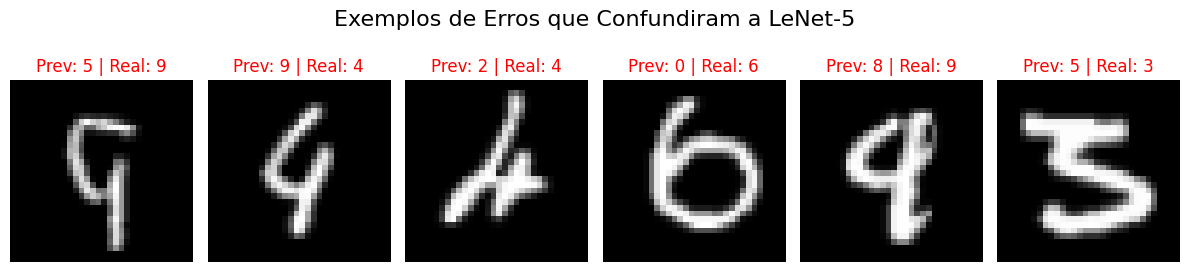

In [7]:
# Vamos iterar novamente sobre o dataset de teste para encontrar onde o modelo errou
model.eval()

errors_images = []
errors_preds = []
errors_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images_device, labels_device = images.to(device), labels.to(device)
        outputs = model(images_device)
        _, predicted = torch.max(outputs.data, 1)
        
        # Criar uma máscara verdadeira para onde a previsão difere do rótulo real
        mask = (predicted != labels_device)
        
        # Filtrar as imagens que a rede errou
        wrong_imgs = images[mask]
        wrong_preds = predicted[mask]
        wrong_lbls = labels[mask]
        
        # Salvar as imagens e as informações para plotar depois
        for i in range(len(wrong_imgs)):
            errors_images.append(wrong_imgs[i])
            errors_preds.append(wrong_preds[i])
            errors_labels.append(wrong_lbls[i])
            
            # Se já pegamos 6 erros, podemos parar para visualizá-los
            if len(errors_images) >= 6:
                break
        if len(errors_images) >= 6:
            break

# Exibir os erros analisados:
if len(errors_images) > 0:
    fig, axes = plt.subplots(1, len(errors_images), figsize=(12, 3))
    
    # Garantir que axes seja iterável se houver apenas 1 erro (muito raro)
    if len(errors_images) == 1:
        axes = [axes]
        
    for i, ax in enumerate(axes):
        img = errors_images[i].squeeze()
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Prev: {errors_preds[i].item()} | Real: {errors_labels[i].item()}', color='red', fontsize=12)
        ax.axis('off')

    plt.suptitle('Exemplos de Erros que Confundiram a LeNet-5', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum erro encontrado! A precisão é 100%!")


---
### 💾 Salvando o Modelo Treinado

Depois de toda a fase de treinamento, alcançamos uma ótima precisão! Para não termos que treinar ou rodar as células anteriores de novo, podemos salvar a "Memória" ou o estado da Inteligência Artificial em um arquivo.

No PyTorch, a maneira mais eficiente para salvar seus modelos é guardando apenas os valores treinados dos pesos (os matrizes matemáticas numéricas geradas) dentro do modelo usando o comando `state_dict`.

In [8]:
# Caminho e nome do arquivo para salvarmos o modelo
PATH = './lenet5_pesos.pth'

# Extraímos o estado e os de pesos atuais de dentro do nosso modelo treinado e salvamos no disco formato ".pth"
torch.save(model.state_dict(), PATH)
print(f"✅ Pesos da LeNet-5 salvos com sucesso no arquivo: {PATH}")


✅ Pesos da LeNet-5 salvos com sucesso no arquivo: ./lenet5_pesos.pth


---
### ⬆️ Carregando o Modelo para Uso

A vantagem de salvar é que a IA virou agora algo muito leve que cabe em um pen-drive ou pode ser enviado para os servidores web.

Basta o programa/servidor web instanciar a estrutura do modelo cru e pedir para injetar o pacote de neurônios treinados a partir do disco, como é demonstrado abaixo.

In [9]:
# 1. Instanciamos a arquitetura do nosso modelo LeNet-5 totalmente do zero, limpinha, sem conhecimento do mundo.
modelo_carregado = LeNet5()

# 2. Lemos o documento de pesos do disco e colamos para que ela absorva automaticamente o conhecimento pre-treinado.
# 'weights_only=True' é uma opção recomendada de segurança da biblioteca PyTorch
modelo_carregado.load_state_dict(torch.load(PATH, weights_only=True))

# 3. Transferimos a nova rede alimentada para a GPU ou placa de vídeo (caso houver)
modelo_carregado.to(device)

# 4. MUITO IMPORTANTE: Antes de colocarmos no app, sempre devemos executar a etapa abaixo de avaliar (.eval())
# Isso desliga lógicas e ferramentas exclusivas da hora de "Estudos" da nossa Maquina
modelo_carregado.eval()

print("📥 Pesos injetados e Modelo carregado de novo com sucesso na CPU/GPU! Ele já está pronto para o combate e uso na avaliação de imagens.")


📥 Pesos injetados e Modelo carregado de novo com sucesso na CPU/GPU! Ele já está pronto para o combate e uso na avaliação de imagens.
